In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [ ]:
def build_backbone():
    base = keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(512,512,3)
    )

    # Freeze early layers
    for layer in base.layers[:100]:
        layer.trainable = False

    return base


In [ ]:
def build_rpn(feature_map, num_anchors=9):

    x = layers.Conv2D(512, 3, padding="same", activation="relu")(feature_map)

    rpn_cls = layers.Conv2D(num_anchors, 1, activation="sigmoid")(x)
    rpn_reg = layers.Conv2D(num_anchors * 4, 1)(x)

    return rpn_cls, rpn_reg


In [ ]:
class ROIAlign(layers.Layer):
    def __init__(self, pool_size=(7,7)):
        super().__init__()
        self.pool_size = pool_size

    def call(self, inputs):
        feature_map, boxes = inputs

        batch_size = tf.shape(feature_map)[0]
        num_boxes = tf.shape(boxes)[1]

        box_indices = tf.repeat(tf.range(batch_size), num_boxes)
        boxes = tf.reshape(boxes, (-1,4))

        pooled = tf.image.crop_and_resize(
            feature_map,
            boxes,
            box_indices,
            self.pool_size
        )

        return pooled


In [ ]:
def build_detection_head(pooled_features, num_classes):

    x = layers.GlobalAveragePooling2D()(pooled_features)
    x = layers.Dense(1024, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    cls_logits = layers.Dense(num_classes, name="cls")(x)
    bbox_reg   = layers.Dense(4*num_classes, name="reg")(x)

    return cls_logits, bbox_reg


In [ ]:
def build_faster_rcnn(num_classes=21):

    inputs = keras.Input(shape=(512,512,3))

    backbone = build_backbone()
    features = backbone(inputs)

    # RPN
    rpn_cls, rpn_reg = build_rpn(features)

    # For demo: random proposals
    proposals = layers.Lambda(
        lambda x: tf.random.uniform((tf.shape(x)[0], 128, 4))
    )(features)

    # ROI Align
    pooled = ROIAlign((7,7))([features, proposals])

    # Detection head
    cls_logits, bbox_reg = build_detection_head(pooled, num_classes)

    model = keras.Model(
        inputs,
        [rpn_cls, rpn_reg, cls_logits, bbox_reg]
    )

    return model

model = build_faster_rcnn(num_classes=21)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 16, 16,    │ 23,587,712 │ input_layer_9[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 128, 4)    │          0 │ resnet50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roi_align_1         │ (None, 7, 7,      │          0 │ resnet50[0][0],   │
│ (ROIAlign)          │ 2048)             │            │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ roi_align_1[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1024)      │  2,098,176 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │  9,437,696 │ resnet50[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1024)      │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16, 9) │      4,617 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │     18,468 │ conv2d_3[0][0]    │
│                     │ 36)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls (Dense)         │ (None, 21)        │     21,525 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg (Dense)         │ (None, 84)        │     86,100 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,254,294 (134.48 MB)

 Trainable params: 31,119,510 (118.71 MB)

 Non-trainable params: 4,134,784 (15.77 MB)

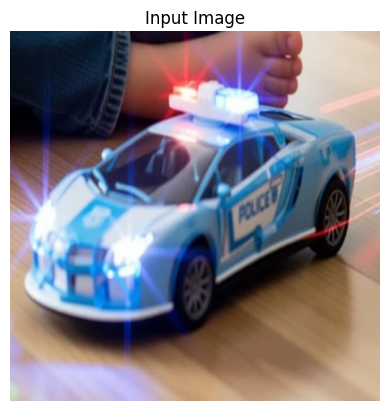

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/car3.png"   # change path
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img, (512, 512))
img_input = img_resized.astype(np.float32) / 255.0
img_input = np.expand_dims(img_input, axis=0)

plt.imshow(img_resized)
plt.title("Input Image")
plt.axis("off")
plt.show()


In [ ]:
def build_faster_rcnn(num_classes=21):

    inputs = keras.Input(shape=(512,512,3))

    backbone = build_backbone()
    features = backbone(inputs)

    # RPN
    rpn_cls, rpn_reg = build_rpn(features)

    # For demo: random proposals
    proposals = layers.Lambda(
        lambda x: tf.random.uniform((tf.shape(x)[0], 128, 4))
    )(features)

    # ROI Align
    pooled = ROIAlign((7,7))([features, proposals])

    # Detection head
    cls_logits, bbox_reg = build_detection_head(pooled, num_classes)

    model = keras.Model(
        inputs,
        [rpn_cls, rpn_reg, cls_logits, bbox_reg]
    )

    return model


In [ ]:
# 2. Simple Anchor Generator (9 anchors per position)
# ────────────────────────────────────────────────
def generate_anchors(feature_map_shape, ratios=[0.5,1,2], scales=[0.5,1,2]):
    """
    Generate anchor boxes for each position in feature map
    Returns: (N,4) → [y1,x1,y2,x2] normalized
    """
    h, w = feature_map_shape[:2]
    anchors = []

    for i in range(h):
        for j in range(w):
            cx = (j + 0.5) / w
            cy = (i + 0.5) / h

            for r in ratios:
                for s in scales:
                    area = s**2
                    w_a = np.sqrt(area / r)
                    h_a = w_a * r
                    x1 = cx - w_a/2
                    y1 = cy - h_a/2
                    x2 = cx + w_a/2
                    y2 = cy + h_a/2
                    anchors.append([y1,x1,y2,x2])

    return np.array(anchors, dtype=np.float32)


In [ ]:
class ROIPooling(layers.Layer):
    def __init__(self, pool_size=(7,7)):
        super().__init__()
        self.pool_size = pool_size

    def call(self, inputs):
        feature_map, boxes = inputs

        batch_size = tf.shape(feature_map)[0]
        num_boxes = tf.shape(boxes)[1]

        box_indices = tf.repeat(tf.range(batch_size), num_boxes)

        boxes_reshaped = tf.reshape(boxes, (-1, 4))

        pooled = tf.image.crop_and_resize(
            feature_map,
            boxes_reshaped,
            box_indices,
            self.pool_size
        )

        return pooled


In [ ]:
def build_simple_detector(num_classes=21):
    inputs = keras.Input(shape=(512,512,3))

    backbone = build_backbone()
    features = backbone(inputs)

    # Fake proposals for lab demo
    proposals = layers.Lambda(
        lambda x: tf.random.uniform((tf.shape(x)[0], 128, 4))
    )(features)

    pooled = ROIPooling((7,7))([features, proposals])

    x = layers.GlobalAveragePooling2D()(pooled)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    class_logits = layers.Dense(num_classes)(x)
    box_deltas = layers.Dense(4*num_classes)(x)

    return keras.Model(inputs, [class_logits, box_deltas])

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────
# 5. Inference demo on sample image
# ────────────────────────────────────────────────
model = build_simple_detector(num_classes=2)
model.summary()

# Load any test image (replace path)
img_path = "/content/car3.png"   # ← put your own image here
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (512, 512))
img_input = np.expand_dims(img_resized.astype(np.float32)/255., 0)

# Dummy inference (random proposals → random results)
cls, reg = model.predict(img_input)

print("Inference done. (This is simplified – real training needed)")

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 16, 16,    │ 23,587,712 │ input_layer_11[0… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 128, 4)    │          0 │ resnet50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roi_pooling_3       │ (None, 7, 7,      │          0 │ resnet50[0][0],   │
│ (ROIPooling)        │ 2048)             │            │ lambda_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ roi_pooling_3[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 512)       │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 2)         │      1,026 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 8)         │      4,104 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,641,930 (94.00 MB)

 Trainable params: 20,507,146 (78.23 MB)

 Non-trainable params: 4,134,784 (15.77 MB)

InvalidArgumentError: Graph execution error:

Detected at node functional_5_1/roi_pooling_3_1/CropAndResize defined at (most recent call last):
<stack traces unavailable>
Detected at node functional_5_1/roi_pooling_3_1/CropAndResize defined at (most recent call last):
<stack traces unavailable>
Detected unsupported operations when trying to compile graph __inference_one_step_on_data_25947[] on XLA_GPU_JIT: CropAndResize (No registered 'CropAndResize' OpKernel for XLA_GPU_JIT devices compatible with node {{node functional_5_1/roi_pooling_3_1/CropAndResize}}){{node functional_5_1/roi_pooling_3_1/CropAndResize}}
The op is created at: 
File "<frozen runpy>", line 198, in _run_module_as_main
File "<frozen runpy>", line 88, in _run_code
File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
File "/usr/local/lib/python3.12/dist-packages/ipykernel/

In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
print("Downloading/Loading fully trained Faster R-CNN model... (This may take a minute)")

Downloading/Loading fully trained Faster R-CNN model... (This may take a minute)


In [3]:
# ---------------------------------------------------------
# 1. MODEL SETUP
# ---------------------------------------------------------
# Load a pre-trained Faster R-CNN model from TF Hub.
# This model uses a ResNet50 backbone and was trained on the COCO dataset.
MODEL_URL = "https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1"
detector = hub.load(MODEL_URL)
print("Model loaded successfully!")

Model loaded successfully!


In [5]:
# ---------------------------------------------------------
# 2. IMAGE PREPROCESSING
# ---------------------------------------------------------
file_path = "/content/img1.jpeg" # Target image for detection

if not os.path.exists(file_path):
    print(f"Error: '{file_path}' not found. Please upload or place the image in the directory.")
else:
    # Read the image using OpenCV
    img = cv2.imread(file_path)

    # OpenCV loads images in BGR format by default.
    # TensorFlow models expect standard RGB format.
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # The model expects a batch of images as a tensor.
    # Convert to tensor and add a batch dimension: [1, Height, Width, 3]
    img_tensor = tf.convert_to_tensor(img_rgb, dtype=tf.uint8)
    img_tensor = tf.expand_dims(img_tensor, 0)

In [6]:
    # ---------------------------------------------------------
# 3. INFERENCE
    # ---------------------------------------------------------
    print("Scanning image for objects...")

    # Run the image through the network.
    # The TF Hub model automatically handles the RPN, ROI Align, and NMS internally.
    results = detector(img_tensor)

    # Extract bounding boxes and confidence scores from the results dictionary.
    # Index [0] is used because we only passed a single image (batch size 1).
    boxes = results["detection_boxes"][0].numpy()
    scores = results["detection_scores"][0].numpy()

Scanning image for objects...


Downloading/Loading fully trained Faster R-CNN model... (This may take a minute)
Model loaded successfully!
Scanning image for objects...


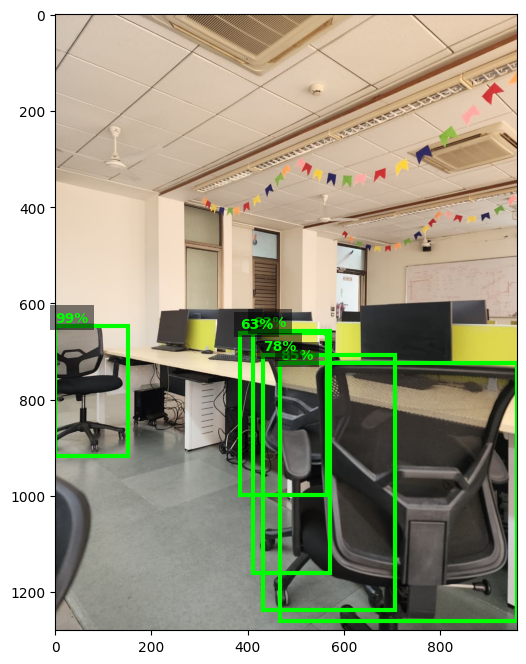

In [10]:

"""
Faster R-CNN Object Detection Pipeline
======================================
This script demonstrates how to load a production-grade, pre-trained
Faster R-CNN model (ResNet50 backbone) from TensorFlow Hub to detect
objects in a static image.

Features:
- Automated Region Proposal and Non-Maximum Suppression (NMS)
- Bounding box extraction and confidence score filtering
- Visualizes and saves the final output using Matplotlib

Usage:
1. Ensure 'object.jpg' is in the same directory as this script.
2. Run the script: `python detect.py`
3. The output will be saved as 'real_detection_output.jpg'.

Dependencies:
- tensorflow, tensorflow_hub, opencv-python, numpy, matplotlib

Author: Raj Antala
"""

import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("Downloading/Loading fully trained Faster R-CNN model... (This may take a minute)")

# ---------------------------------------------------------
# 1. MODEL SETUP
# ---------------------------------------------------------
# Load a pre-trained Faster R-CNN model from TF Hub.
# This model uses a ResNet50 backbone and was trained on the COCO dataset.
MODEL_URL = "https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1"
detector = hub.load(MODEL_URL)
print("Model loaded successfully!")

# ---------------------------------------------------------
# 2. IMAGE PREPROCESSING
# ---------------------------------------------------------
file_path = "/content/img1.jpeg" # Target image for detection

if not os.path.exists(file_path):
    print(f"Error: '{file_path}' not found. Please upload or place the image in the directory.")
else:
    # Read the image using OpenCV
    img = cv2.imread(file_path)

    # OpenCV loads images in BGR format by default.
    # TensorFlow models expect standard RGB format.
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # The model expects a batch of images as a tensor.
    # Convert to tensor and add a batch dimension: [1, Height, Width, 3]
    img_tensor = tf.convert_to_tensor(img_rgb, dtype=tf.uint8)
    img_tensor = tf.expand_dims(img_tensor, 0)

    # ---------------------------------------------------------
# 3. INFERENCE
    # ---------------------------------------------------------
    print("Scanning image for objects...")

    # Run the image through the network.
    # The TF Hub model automatically handles the RPN, ROI Align, and NMS internally.
    results = detector(img_tensor)

    # Extract bounding boxes and confidence scores from the results dictionary.
    # Index [0] is used because we only passed a single image (batch size 1).
    boxes = results["detection_boxes"][0].numpy()
    scores = results["detection_scores"][0].numpy()

    # ---------------------------------------------------------
# 4. VISUALIZATION & EXPORT
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)

    # Get image dimensions to scale the normalized bounding box coordinates
    h, w, _ = img_rgb.shape

    # Set a confidence threshold to filter out weak/background predictions
    min_confidence = 0.50
    detections = 0

    for i in range(len(scores)):
        if scores[i] >= min_confidence:
            detections += 1

            # The model outputs normalized coordinates between 0 and 1
            # Format: [ymin, xmin, ymax, xmax]
            ymin, xmin, ymax, xmax = boxes[i]

            # Convert normalized coordinates to absolute pixel coordinates
            y1, x1 = int(ymin * h), int(xmin * w)
            y2, x2 = int(ymax * h), int(xmax * w)

            # Draw the bounding box (Green)
            plt.gca().add_patch(
                plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='#00ff00', linewidth=3)
            )

            # Draw the confidence score label
            score_text = f"{scores[i]*100:.0f}%"
            plt.text(
                x1, y1 - 10, score_text, color='#00ff00', fontsize=10, weight='bold',
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

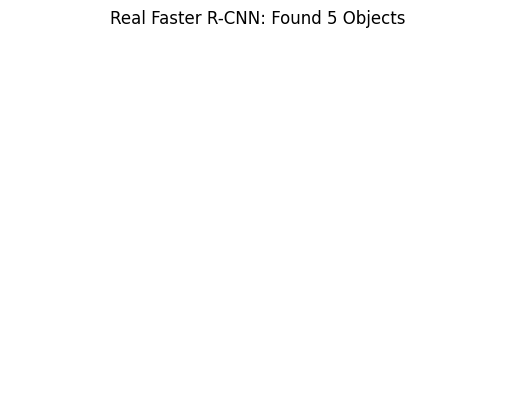

Success! Dynamically detected 5 objects in your image.
Saved visualization to: real_detection_output.jpg


In [11]:
    # Render and save the final image
    plt.title(f"Real Faster R-CNN: Found {detections} Objects")
    plt.axis('off')

    output_filename = "real_detection_output.jpg"
    plt.savefig(output_filename, bbox_inches='tight')
    plt.show()

    print(f"Success! Dynamically detected {detections} objects in your image.")
    print(f"Saved visualization to: {output_filename}")